In [1]:
import pandas as pd
import numpy as np
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
import re
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ExeterReviews.csv")

In [3]:
df = df.reset_index()

In [4]:
df.head()

,index,Member ID,Date,Review,Student Review,Campus/Facilities,Club/Societies,Careers Service,Wifi/Internet
0,0,887111.0,1st June 23,I like my university very much!,5.0,5,5,5,5
1,1,1287025.0,31st May 23,"I am from the USA, so I am comparing my experi...",3.4,3,3,3,5
2,2,1286468.0,20th May 23,Exeter University is generally a lovely place ...,4.0,5,4,4,3
3,3,486467.0,20th May 23,Nice facilities and some great lecturers! The ...,4.4,4,4,4,5
4,4,486456.0,19th May 23,The uni is good they provide me with alot of s...,4.8,5,5,5,5


In [5]:
for i in df.columns:
    print(i, type(i))

index <class 'str'>
Member ID <class 'str'>
Date <class 'str'>
Review <class 'str'>
Student Review <class 'str'>
Campus/Facilities <class 'str'>
Club/Societies <class 'str'>
Careers Service <class 'str'>
Wifi/Internet <class 'str'>


In [6]:
df = df.fillna(0)

In [7]:
def str2int(df,cols):
    for c in cols:
        df[c] = df[c].astype(int)
    return df
        

In [8]:
str2int(df,['Campus/Facilities', 'Club/Societies', 'Careers Service', 'Wifi/Internet'])

,index,Member ID,Date,Review,Student Review,Campus/Facilities,Club/Societies,Careers Service,Wifi/Internet
0,0,887111.0,1st June 23,I like my university very much!,5.0,5,5,5,5
1,1,1287025.0,31st May 23,"I am from the USA, so I am comparing my experi...",3.4,3,3,3,5
2,2,1286468.0,20th May 23,Exeter University is generally a lovely place ...,4.0,5,4,4,3
3,3,486467.0,20th May 23,Nice facilities and some great lecturers! The ...,4.4,4,4,4,5
4,4,486456.0,19th May 23,The uni is good they provide me with alot of s...,4.8,5,5,5,5
...,...,...,...,...,...,...,...,...,...
552,552,0.0,25th March 15,Brilliant university; beautiful campus; active...,4.7,5,5,5,5
553,553,0.0,25th March 15,Sport membership is very expensive,4.3,4,5,5,5
554,554,0.0,25th March 15,It is great! But there should be a swimming po...,4.3,4,5,5,5
555,555,0.0,25th March 15,ITS AMAZING! I love my university and wouldn't...,4.7,5,5,5,5


<AxesSubplot:title={'center':'Exeter Uni ratings according to students'}>

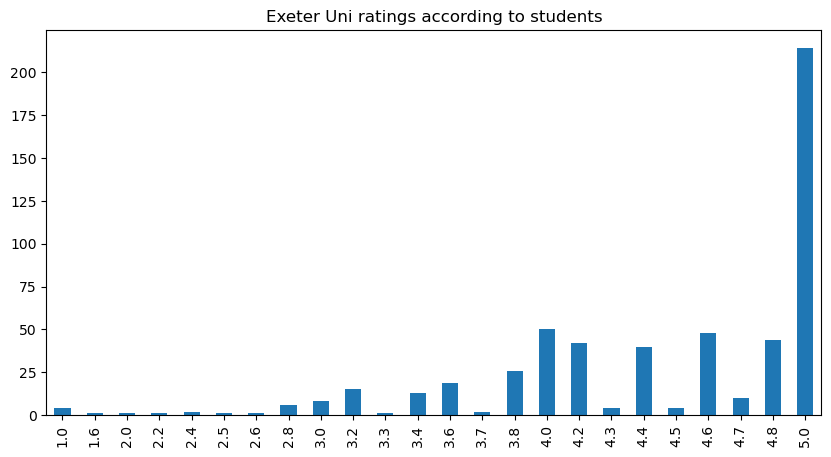

In [9]:
df['Student Review'].value_counts().sort_index().plot(kind='bar', title="Exeter Uni ratings according to students", 
                                                      figsize=(10,5))

In [10]:
ex = df['Review'][5] 

In [11]:
ex

'Exeter university has been great! An extremely supportive university I have enjoyed my three years being here.'

In [12]:
tokens = nltk.word_tokenize(ex)

In [13]:
tagged = nltk.pos_tag(tokens)

In [14]:
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  (GPE Exeter/NNP)
  university/NN
  has/VBZ
  been/VBN
  great/JJ
  !/.
  An/DT
  extremely/RB
  supportive/JJ
  university/NN
  I/PRP
  have/VBP
  enjoyed/VBN
  my/PRP$
  three/CD
  years/NNS
  being/VBG
  here/RB
  ./.)


In [15]:
sia = SentimentIntensityAnalyzer()

In [16]:
sia.polarity_scores('I am so happy!')

{'neg': 0.0, 'neu': 0.318, 'pos': 0.682, 'compound': 0.6468}

In [17]:
sia.polarity_scores("This is the worst thing ever")

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [18]:
ex

'Exeter university has been great! An extremely supportive university I have enjoyed my three years being here.'

In [19]:
sia.polarity_scores(ex)

{'neg': 0.0, 'neu': 0.561, 'pos': 0.439, 'compound': 0.8803}

In [20]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Review']
    myid = row['index']
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/557 [00:00<?, ?it/s]

In [21]:
res

{0: {'neg': 0.0, 'neu': 0.589, 'pos': 0.411, 'compound': 0.4199},
 1: {'neg': 0.038, 'neu': 0.895, 'pos': 0.067, 'compound': 0.6738},
 2: {'neg': 0.089, 'neu': 0.724, 'pos': 0.187, 'compound': 0.4497},
 3: {'neg': 0.0, 'neu': 0.787, 'pos': 0.213, 'compound': 0.8699},
 4: {'neg': 0.0, 'neu': 0.736, 'pos': 0.264, 'compound': 0.8225},
 5: {'neg': 0.0, 'neu': 0.561, 'pos': 0.439, 'compound': 0.8803},
 6: {'neg': 0.0, 'neu': 0.561, 'pos': 0.439, 'compound': 0.8553},
 7: {'neg': 0.0, 'neu': 0.446, 'pos': 0.554, 'compound': 0.8271},
 8: {'neg': 0.047, 'neu': 0.743, 'pos': 0.21, 'compound': 0.8271},
 9: {'neg': 0.0, 'neu': 0.853, 'pos': 0.147, 'compound': 0.7738},
 10: {'neg': 0.086, 'neu': 0.602, 'pos': 0.312, 'compound': 0.9081},
 11: {'neg': 0.0, 'neu': 0.768, 'pos': 0.232, 'compound': 0.9184},
 12: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0},
 13: {'neg': 0.0, 'neu': 0.649, 'pos': 0.351, 'compound': 0.8828},
 14: {'neg': 0.0, 'neu': 0.788, 'pos': 0.212, 'compound': 0.6872},
 15: 

In [22]:
vaders = pd.DataFrame(res).T

In [23]:
vaders = vaders.reset_index()
vaders = vaders.merge(df, how='left')

In [24]:
vaders

,index,neg,neu,pos,compound,Member ID,Date,Review,Student Review,Campus/Facilities,Club/Societies,Careers Service,Wifi/Internet
0,0,0.000,0.589,0.411,0.4199,887111.0,1st June 23,I like my university very much!,5.0,5,5,5,5
1,1,0.038,0.895,0.067,0.6738,1287025.0,31st May 23,"I am from the USA, so I am comparing my experi...",3.4,3,3,3,5
2,2,0.089,0.724,0.187,0.4497,1286468.0,20th May 23,Exeter University is generally a lovely place ...,4.0,5,4,4,3
3,3,0.000,0.787,0.213,0.8699,486467.0,20th May 23,Nice facilities and some great lecturers! The ...,4.4,4,4,4,5
4,4,0.000,0.736,0.264,0.8225,486456.0,19th May 23,The uni is good they provide me with alot of s...,4.8,5,5,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,552,0.000,0.402,0.598,0.9746,0.0,25th March 15,Brilliant university; beautiful campus; active...,4.7,5,5,5,5
553,553,0.000,1.000,0.000,0.0000,0.0,25th March 15,Sport membership is very expensive,4.3,4,5,5,5
554,554,0.000,0.795,0.205,0.4295,0.0,25th March 15,It is great! But there should be a swimming po...,4.3,4,5,5,5
555,555,0.000,0.499,0.501,0.8757,0.0,25th March 15,ITS AMAZING! I love my university and wouldn't...,4.7,5,5,5,5


<AxesSubplot:xlabel='Student Review', ylabel='compound'>

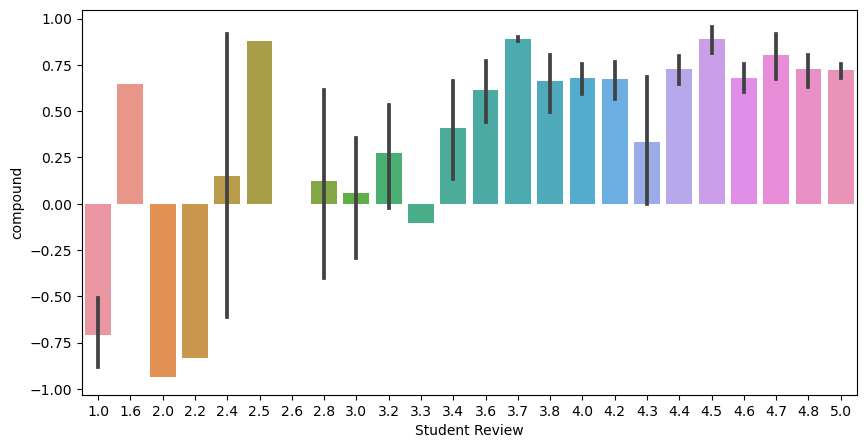

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(data=vaders, x='Student Review', y='compound')

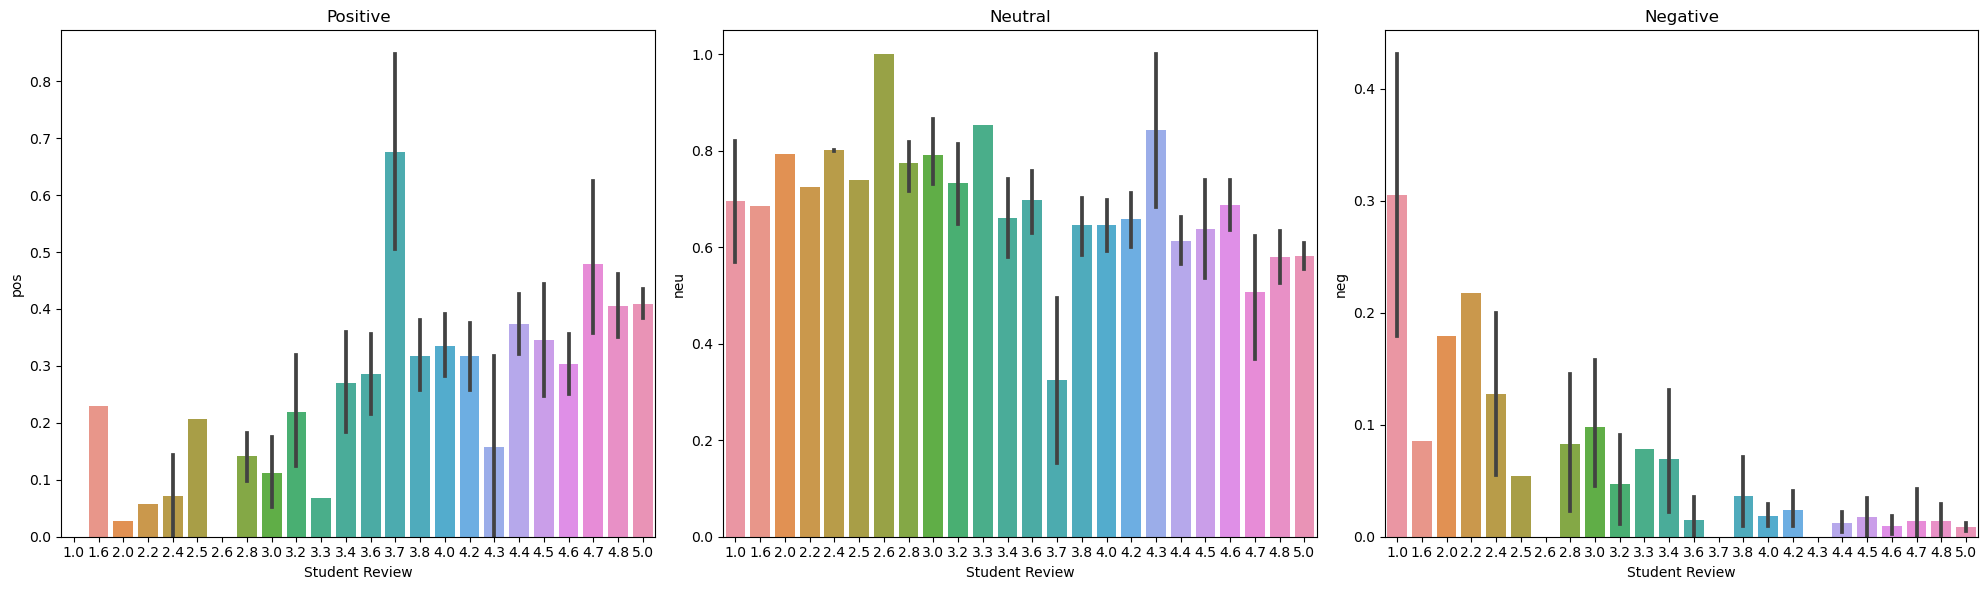

In [26]:
fig, axs = plt.subplots(1,3, figsize=(20,6))
sns.barplot(data=vaders, x='Student Review', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='Student Review', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='Student Review', y='neg', ax=axs[2])
axs[0].set_title("Positive")
axs[1].set_title("Neutral")
axs[2].set_title("Negative")
plt.tight_layout()
plt.show()

***Transformers***

In [27]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [28]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

C:\Users\rohit\anaconda3\lib\site-packages\huggingface_hub\file_download.py:133: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rohit\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [29]:
ex

'Exeter university has been great! An extremely supportive university I have enjoyed my three years being here.'

In [32]:
#Roberta Model

encoded_text = tokenizer(ex, return_tensors='pt')
output = model(**encoded_text)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2],
    
}
print(scores_dict)

{'roberta_neg': 0.0015856, 'roberta_neu': 0.005613238, 'roberta_pos': 0.9928012}


In [33]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(ex, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2],

    }
    return scores_dict

In [44]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        
        text = row['Review']
        myid = row['index']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
        
    except RuntimeError:
        print(f'Broke for id {my}')
    

  0%|          | 0/557 [00:00<?, ?it/s]

In [45]:
res

{0: {'vader_neg': 0.0,
  'vader_neu': 0.589,
  'vader_pos': 0.411,
  'vader_compound': 0.4199,
  'roberta_neg': 0.0015856,
  'roberta_neu': 0.005613238,
  'roberta_pos': 0.9928012},
 1: {'vader_neg': 0.038,
  'vader_neu': 0.895,
  'vader_pos': 0.067,
  'vader_compound': 0.6738,
  'roberta_neg': 0.0015856,
  'roberta_neu': 0.005613238,
  'roberta_pos': 0.9928012},
 2: {'vader_neg': 0.089,
  'vader_neu': 0.724,
  'vader_pos': 0.187,
  'vader_compound': 0.4497,
  'roberta_neg': 0.0015856,
  'roberta_neu': 0.005613238,
  'roberta_pos': 0.9928012},
 3: {'vader_neg': 0.0,
  'vader_neu': 0.787,
  'vader_pos': 0.213,
  'vader_compound': 0.8699,
  'roberta_neg': 0.0015856,
  'roberta_neu': 0.005613238,
  'roberta_pos': 0.9928012},
 4: {'vader_neg': 0.0,
  'vader_neu': 0.736,
  'vader_pos': 0.264,
  'vader_compound': 0.8225,
  'roberta_neg': 0.0015856,
  'roberta_neu': 0.005613238,
  'roberta_pos': 0.9928012},
 5: {'vader_neg': 0.0,
  'vader_neu': 0.561,
  'vader_pos': 0.439,
  'vader_compound':

In [51]:
result_df = pd.DataFrame(res).T
result_df = result_df.reset_index()
result_df = result_df.merge(df, how='left')

In [52]:
result_df

,index,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos,Member ID,Date,Review,Student Review,Campus/Facilities,Club/Societies,Careers Service,Wifi/Internet
0,0,0.000,0.589,0.411,0.4199,0.001586,0.005613,0.992801,887111.0,1st June 23,I like my university very much!,5.0,5,5,5,5
1,1,0.038,0.895,0.067,0.6738,0.001586,0.005613,0.992801,1287025.0,31st May 23,"I am from the USA, so I am comparing my experi...",3.4,3,3,3,5
2,2,0.089,0.724,0.187,0.4497,0.001586,0.005613,0.992801,1286468.0,20th May 23,Exeter University is generally a lovely place ...,4.0,5,4,4,3
3,3,0.000,0.787,0.213,0.8699,0.001586,0.005613,0.992801,486467.0,20th May 23,Nice facilities and some great lecturers! The ...,4.4,4,4,4,5
4,4,0.000,0.736,0.264,0.8225,0.001586,0.005613,0.992801,486456.0,19th May 23,The uni is good they provide me with alot of s...,4.8,5,5,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,552,0.000,0.402,0.598,0.9746,0.001586,0.005613,0.992801,0.0,25th March 15,Brilliant university; beautiful campus; active...,4.7,5,5,5,5
553,553,0.000,1.000,0.000,0.0000,0.001586,0.005613,0.992801,0.0,25th March 15,Sport membership is very expensive,4.3,4,5,5,5
554,554,0.000,0.795,0.205,0.4295,0.001586,0.005613,0.992801,0.0,25th March 15,It is great! But there should be a swimming po...,4.3,4,5,5,5
555,555,0.000,0.499,0.501,0.8757,0.001586,0.005613,0.992801,0.0,25th March 15,ITS AMAZING! I love my university and wouldn't...,4.7,5,5,5,5


In [53]:
result_df.columns

Index(['index', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'Member ID', 'Date',
       'Review', 'Student Review', 'Campus/Facilities', 'Club/Societies',
       'Careers Service', 'Wifi/Internet'],
      dtype='object')

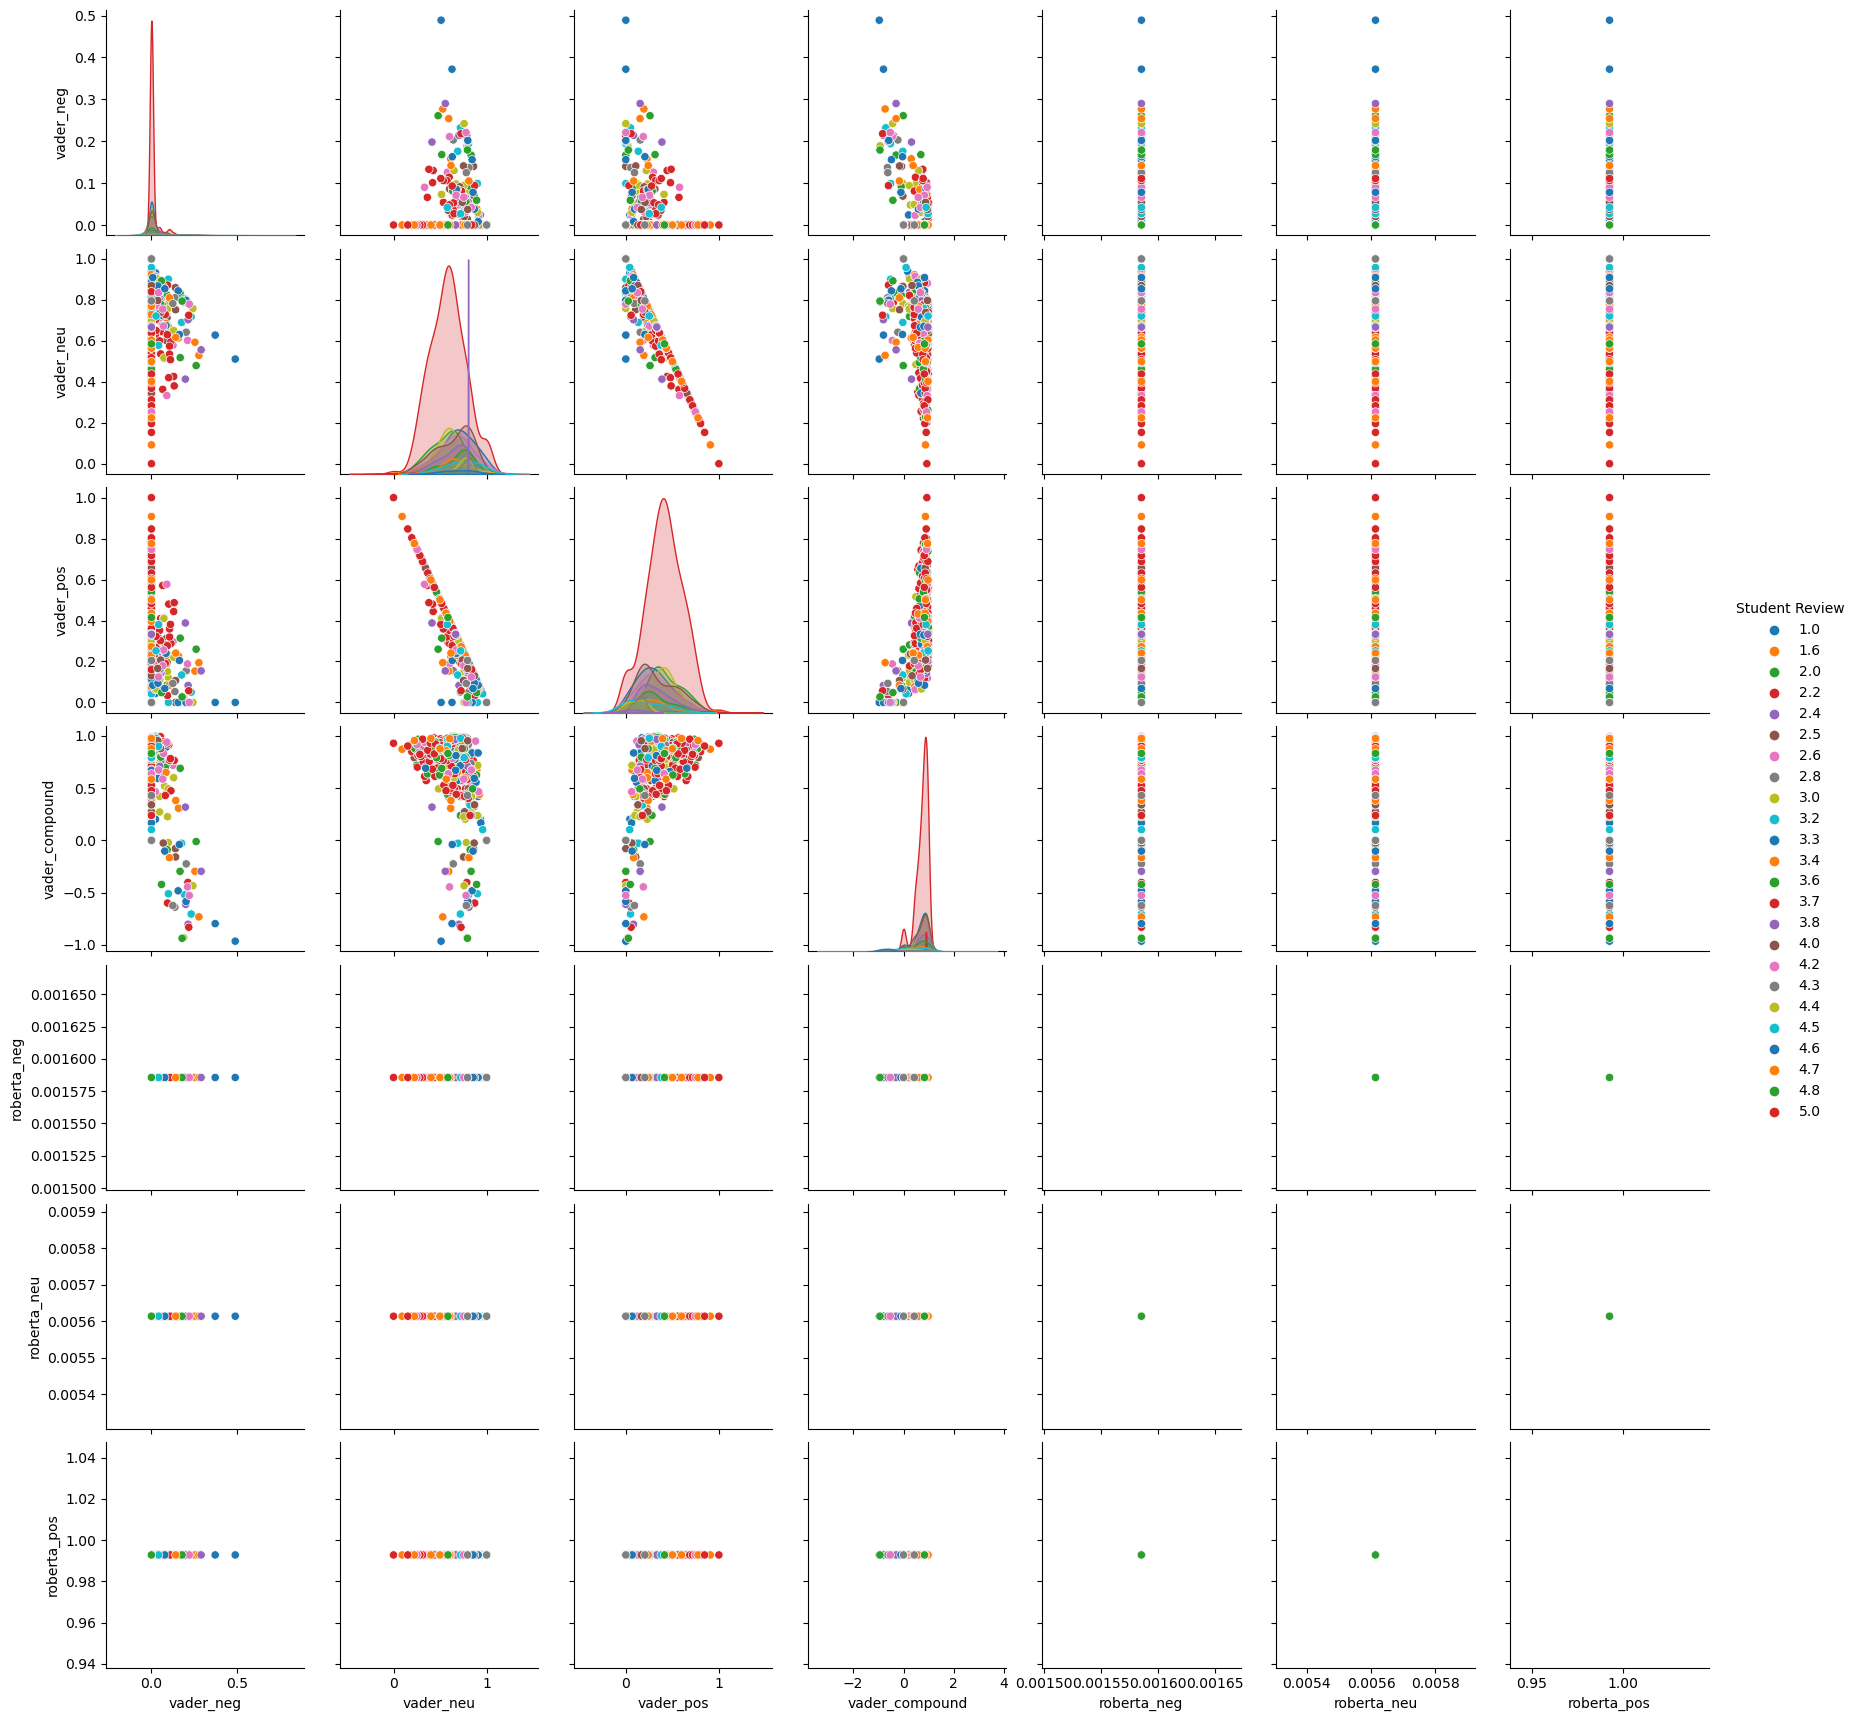

In [55]:
sns.pairplot(data=result_df,
            vars=['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='Student Review',
            palette='tab10')
plt.show()

In [68]:
from transformers import pipeline

In [70]:
sent_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Xformers is not installed correctly. If you want to use memory_efficient_attention to accelerate training use the following command to install Xformers
pip install xformers.


In [73]:
sent_pipeline(df['Review'][])

[{'label': 'NEGATIVE', 'score': 0.9970794916152954}]